# Data Generation

In [20]:
%matplotlib inline
import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt

dim_theta = 10
data_num = 1000
scale = .1

theta_true = np.ones((dim_theta,1))
print('True theta:', theta_true.reshape(-1))

A = np.random.uniform(low=-1.0, high=1.0, size=(data_num,dim_theta))
y_data = A @ theta_true + np.random.normal(loc=0.0, scale=scale, size=(data_num, 1))

A_test = np.random.uniform(low=-1.0, high=1.0, size=(50, dim_theta))
y_test = A_test @ theta_true + np.random.normal(loc=0.0, scale=scale, size=(50, 1))

True theta: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


# Solving for the exact mean squared loss (solving Ax = b)

In [21]:
print('Not implemented.')

'''
Hints:
1. See the least squares solution to Ax = b (when it is covered in lecture).

2. Use Numpy functions like Numpy's linear algebra functions to solve for x in Ax = b.
In fact, the linear algebra module is already imported with ```import numpy.linalg as la```.

3. Use the defined variable A in Ax = b. Use y_data as b. Use theta_pred as x.
'''
b = y_data
theta_pred, *_ = la.lstsq(A, b, rcond=None)

print('Empirical theta', theta_pred.reshape(-1))

Not implemented.
Empirical theta [1.00537871 1.00164512 1.01293308 0.99639874 0.99279783 0.99983552
 0.9976377  1.01067064 0.99240779 1.0062373 ]


# SGD Variants Noisy Function

In [22]:
batch_size = 1
max_iter = 1000
lr = 0.001
theta_init = np.random.random((10,1)) * 0.1

In [23]:
def noisy_val_grad(theta_hat, data_, label_, deg_=2.):
    gradient = np.zeros_like(theta_hat)
    loss = 0.0

    for i in range(data_.shape[0]):
        x_ = data_[i, :].reshape(-1, 1)
        y_ = label_[i, 0]
        err = np.sum(x_ * theta_hat) - y_
        l = np.abs(err) ** deg_
        grad = deg_ * (np.abs(err) ** (deg_ - 1)) * np.sign(err) * x_
        loss += l / data_.shape[0]
        gradient += grad / data_.shape[0]

    return loss, gradient

# Running SGD Variants

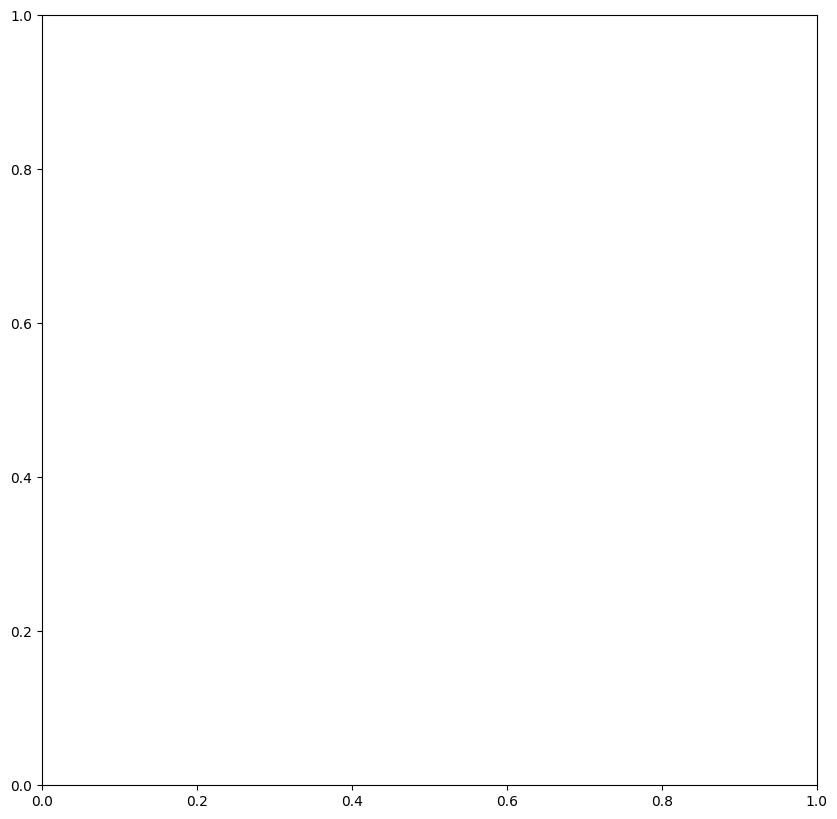

In [24]:
#@title Parameters
deg_ = 2. #@param {type: "number"}
num_rep = 10 #@param {type: "integer"}
max_iter = 1000 #@param {type: "integer"}
fig, ax = plt.subplots(figsize=(10,10))
best_vals = {}
test_exp_interval = 50 #@param {type: "integer"}
grad_artificial_normal_noise_scale = 0. #@param {type: "number"}

adam replicate 0
Method adam, replicate 0: theta_hat = [0.23448649 0.21904929 0.16269237 0.18517618 0.19318333 0.14807851
 0.17843703 0.22128521 0.170741   0.14875973]
Method adam, replicate 1: theta_hat = [0.19013244 0.18780495 0.13701498 0.22397205 0.18483126 0.11720372
 0.15874671 0.18715502 0.16200237 0.15432449]
Method adam, replicate 2: theta_hat = [0.26763136 0.23999694 0.20378695 0.25962067 0.24757359 0.19569594
 0.19004117 0.24839657 0.23480735 0.26797161]
Method adam, replicate 3: theta_hat = [0.22416452 0.20648634 0.18716302 0.23918301 0.23246958 0.19777075
 0.23069953 0.18601156 0.19272125 0.22521134]
Method adam, replicate 4: theta_hat = [0.28978423 0.24799119 0.21732468 0.23495696 0.2485905  0.21373914
 0.22381616 0.26402585 0.2507546  0.22431053]
Method adam, replicate 5: theta_hat = [0.27535664 0.24121911 0.17228853 0.207022   0.21788833 0.17795826
 0.23040767 0.22129266 0.22313717 0.19650852]
Method adam, replicate 6: theta_hat = [0.22628444 0.21523939 0.17743676 0.228

/tmp/ipython-input-2919030120.py:9: RuntimeWarning: overflow encountered in scalar power
  l = np.abs(err) ** deg_
/tmp/ipython-input-2919030120.py:10: RuntimeWarning: overflow encountered in scalar power
  grad = deg_ * (np.abs(err) ** (deg_ - 1)) * np.sign(err) * x_
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


Method sgd, replicate 2: theta_hat = [nan nan nan nan nan nan nan nan nan nan]
Method sgd, replicate 3: theta_hat = [1.11969438 0.92187585 0.89918295 0.79065297 0.81144826 0.56780337
 0.83956612 0.85366022 0.86383067 0.97195087]
Method sgd, replicate 4: theta_hat = [0.88965305 0.8503599  0.82698218 0.87703989 0.7676208  0.90754744
 0.86677316 0.89228031 0.79702375 0.71547284]
Method sgd, replicate 5: theta_hat = [0.93085793 0.84243571 0.9538038  0.84565418 0.8320974  1.02240189
 0.52131946 1.03012894 0.82295385 0.97114896]
Method sgd, replicate 6: theta_hat = [0.90617418 0.98686796 0.77015683 0.78433484 0.63977255 0.93563585
 0.81256512 0.93007383 0.76050264 1.00422517]
Method sgd, replicate 7: theta_hat = [0.78619976 0.85469824 0.95608131 0.98230535 0.68723962 0.67879703
 0.87789396 0.92482454 0.78631697 0.97200382]
Method sgd, replicate 8: theta_hat = [0.79753858 0.73779081 1.03513158 0.75991604 0.82993186 0.77033305
 0.87692106 0.84086897 1.01156385 0.79667431]
Method sgd, replicate

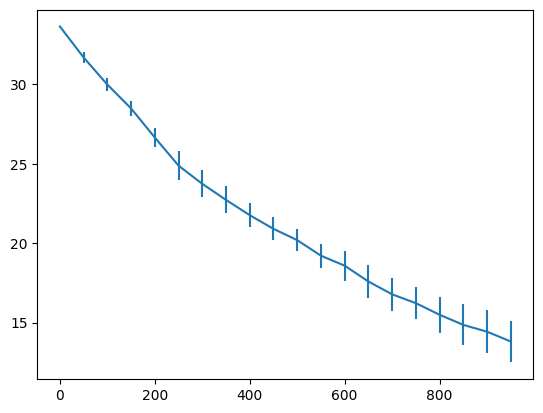

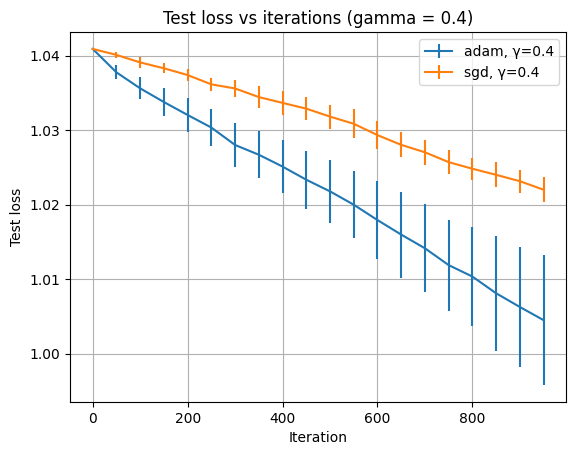


==== Running Adam and SGD with gamma = 0.7 ====
adam replicate 0
Mean test loss for adam, gamma=0.7: [1.13390086 1.12708022 1.11998598 1.11313122 1.10579382 1.09892125
 1.09128228 1.08305051 1.07545154 1.06813946 1.06108633 1.05329376
 1.04499504 1.03789086 1.03058156 1.02305176 1.01530776 1.00748541
 1.0002484  0.99239329]
sgd replicate 0
Mean test loss for sgd, gamma=0.7: [1.13390086 1.13053132 1.12684493 1.12309718 1.11957323 1.11585157
 1.11238784 1.10876518 1.10551719 1.10154216 1.09827713 1.09456856
 1.09084242 1.08702892 1.08371405 1.07979809 1.07629215 1.07300448
 1.06928698 1.06529652]


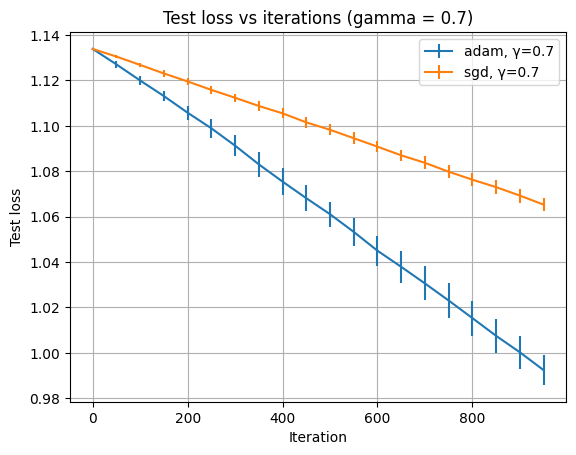


==== Running Adam and SGD with gamma = 1.0 ====
adam replicate 0
Mean test loss for adam, gamma=1.0: [1.28186608 1.26372255 1.24699164 1.23055999 1.21352447 1.1970649
 1.18090873 1.16332494 1.147894   1.13088639 1.11430571 1.09806953
 1.08148132 1.06547792 1.04855723 1.03146258 1.01548236 0.99962521
 0.98262426 0.96564044]
sgd replicate 0
Mean test loss for sgd, gamma=1.0: [1.28186608 1.27274866 1.26286205 1.2534701  1.24341928 1.23320835
 1.22318056 1.21328561 1.20333039 1.19270271 1.18292671 1.17298209
 1.16366958 1.15489655 1.14468392 1.13440925 1.12315188 1.11225936
 1.10283715 1.09246427]


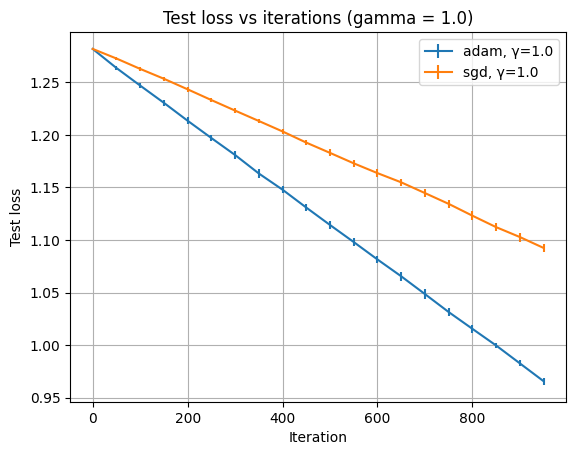


==== Running Adam and SGD with gamma = 2.0 ====
adam replicate 0
Mean test loss for adam, gamma=2.0: [2.34286736 2.27495081 2.20654522 2.13184405 2.06653906 1.99415512
 1.93273548 1.86879013 1.80997638 1.74660786 1.68945898 1.63381629
 1.58117034 1.52603458 1.47787011 1.43029366 1.38218715 1.3381617
 1.29213831 1.24714591]
sgd replicate 0
Mean test loss for sgd, gamma=2.0: [2.34286736 2.19793317 2.06059312 1.9263207  1.79871155 1.68073886
 1.58193303 1.4838738  1.38398117 1.30252517 1.21760807 1.14198397
 1.07297666 1.0016317  0.93845962 0.88257449 0.82807638 0.77501416
 0.72137999 0.67277151]


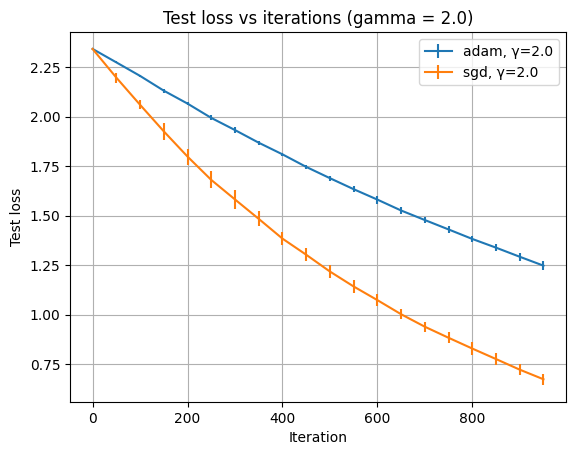


==== Running Adam and SGD with gamma = 3.0 ====
adam replicate 0
Mean test loss for adam, gamma=3.0: [5.1915128  4.97268109 4.77266654 4.59463457 4.39568982 4.20158105
 4.01877705 3.85769886 3.71447785 3.54763857 3.39950473 3.26279211
 3.14546785 3.02929708 2.9145879  2.79236386 2.69082626 2.58080384
 2.47259955 2.37453807]
sgd replicate 0
Mean test loss for sgd, gamma=3.0: [5.1915128  3.40912028 2.36739894 1.78264558 1.33842625 1.0690688
 0.89568299 0.69684114 0.57334065 0.46985927 0.39402686 0.33901087
 0.28304029 0.24070046 0.2129463  0.18528693 0.16793538 0.15013264
 0.13343481 0.11952709]


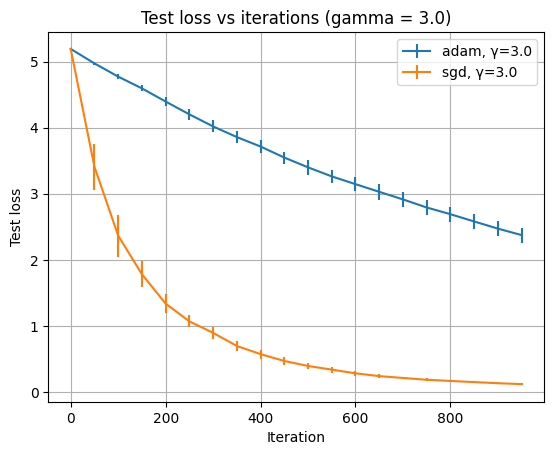


==== Running Adam and SGD with gamma = 5.0 ====
adam replicate 0
Mean test loss for adam, gamma=5.0: [33.64121603 31.69351482 29.8017267  28.10254066 26.65674426 25.36615482
 24.3315759  23.26645498 21.86718034 20.80650108 20.03363697 19.15297943
 18.49616233 17.59233537 16.84496797 16.00132202 15.44585405 14.81555547
 14.32472355 13.68801111]
sgd replicate 0
Mean test loss for sgd, gamma=5.0: [3.36412160e+01 2.31206472e+00 7.25332994e-01 3.90990756e-01
 2.02219069e-01 1.47310367e-01 1.09402145e-01 8.69723245e-02
 7.33553005e-02 6.05898156e-02 5.30417723e-02 4.76803893e-02
 4.00485326e-02 3.47211722e-02 3.10442504e-02 2.76144219e-02
 2.49759715e-02 2.26122424e-02 2.06525590e-02 1.93706488e-02]


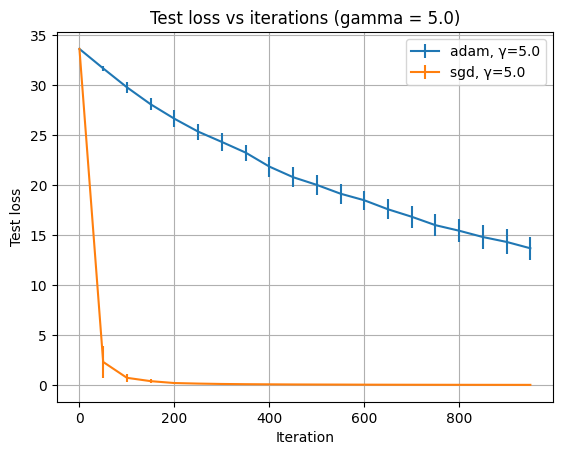

In [27]:
for method_idx, method in enumerate(['adam', 'sgd']):  # you can add 'adagrad' back if you want
    test_loss_mat = []
    train_loss_mat = []

    for replicate in range(num_rep):
        if replicate % 20 == 0:
            print(method, "replicate", replicate)

        # initialize optimizer-specific state
        if method == 'adam':
            beta_1 = 0.9
            beta_2 = 0.999
            m = np.zeros_like(theta_init)      # first moment
            v = np.zeros_like(theta_init)      # second moment
            epsilon = 1e-8

        if method == 'adagrad':
            epsilon = 1e-8
            squared_sum = np.zeros_like(theta_init)

        theta_hat = theta_init.copy()
        test_loss_list = []
        train_loss_list = []

        for t in range(max_iter):
            idx = np.random.choice(data_num, batch_size)  # mini-batch indices
            train_loss, gradient = noisy_val_grad(theta_hat, A[idx, :], y_data[idx, :], deg_=deg_)

            artificial_grad_noise = (
                np.random.randn(10, 1) * grad_artificial_normal_noise_scale
                + np.sign(np.random.random((10, 1)) - 0.5) * 0.
            )
            gradient = gradient + artificial_grad_noise
            train_loss_list.append(train_loss)

            if t % test_exp_interval == 0:
                test_loss, _ = noisy_val_grad(theta_hat, A_test[:, :], y_test[:, :], deg_=deg_)
                test_loss_list.append(test_loss)

            # === optimizer updates ===
            if method == 'adam':
                # ADAM update
                t_step = t + 1  # time step starts from 1
                m = beta_1 * m + (1.0 - beta_1) * gradient
                v = beta_2 * v + (1.0 - beta_2) * (gradient ** 2)

                # bias-corrected moments
                m_hat = m / (1.0 - beta_1 ** t_step)
                v_hat = v / (1.0 - beta_2 ** t_step)

                theta_hat = theta_hat - lr * m_hat / (np.sqrt(v_hat) + epsilon)

            elif method == 'adagrad':
                squared_sum = squared_sum + gradient ** 2
                theta_hat = theta_hat - lr * gradient / (np.sqrt(squared_sum) + epsilon)

            elif method == 'sgd':
                theta_hat = theta_hat - lr * gradient

        # end of one replicate
        print(f"Method {method}, replicate {replicate}: theta_hat = {theta_hat.reshape(-1)}")
        test_loss_mat.append(test_loss_list)
        train_loss_mat.append(train_loss_list)

    print(method, 'done')
    x_axis = np.arange(max_iter)[::test_exp_interval]

    print('test_loss_np is a 2d array with num_rep rows and each column denotes a specific update stage in training')
    print('The elements of test_loss_np are the test loss values computed in each replicate and training stage.')
    test_loss_np = np.array(test_loss_mat)

    # 4.4: mean and standard error
    test_loss_mean = np.mean(test_loss_np, axis=0)
    test_loss_se = np.std(test_loss_np, axis=0) / np.sqrt(num_rep)

    print("Mean test loss for", method, ":", test_loss_mean)
    print("Std error for", method, ":", test_loss_se)

    plt.errorbar(x_axis, test_loss_mean, yerr=2.5 * test_loss_se, label=method)
    best_vals[method] = min(test_loss_mean)


gammas = [0.4, 0.7, 1.0, 2.0, 3.0, 5.0]

for deg_ in gammas:
    print(f"\n==== Running Adam and SGD with gamma = {deg_} ====")

    plt.figure()

    for method in ['adam', 'sgd']:
        test_loss_mat = []
        train_loss_mat = []

        for replicate in range(num_rep):
            if replicate % 20 == 0:
                print(f"{method} replicate {replicate}")

            # --- optimizer-specific init ---
            if method == 'adam':
                beta_1 = 0.9
                beta_2 = 0.999
                m = np.zeros_like(theta_init)
                v = np.zeros_like(theta_init)
                epsilon = 1e-8

            theta_hat = theta_init.copy()
            test_loss_list = []
            train_loss_list = []

            for t in range(max_iter):
                # mini-batch
                idx = np.random.choice(data_num, batch_size)
                train_loss, gradient = noisy_val_grad(theta_hat, A[idx, :], y_data[idx, :], deg_=deg_)

                # artificial gradient noise
                artificial_grad_noise = (
                    np.random.randn(10, 1) * grad_artificial_normal_noise_scale
                    + np.sign(np.random.random((10, 1)) - 0.5) * 0.
                )
                gradient = gradient + artificial_grad_noise
                train_loss_list.append(train_loss)

                # test loss at intervals
                if t % test_exp_interval == 0:
                    test_loss, _ = noisy_val_grad(theta_hat, A_test[:, :], y_test[:, :], deg_=deg_)
                    test_loss_list.append(test_loss)

                # --- updates ---
                if method == 'adam':
                    t_step = t + 1
                    m = beta_1 * m + (1.0 - beta_1) * gradient
                    v = beta_2 * v + (1.0 - beta_2) * (gradient ** 2)

                    m_hat = m / (1.0 - beta_1 ** t_step)
                    v_hat = v / (1.0 - beta_2 ** t_step)

                    theta_hat = theta_hat - lr * m_hat / (np.sqrt(v_hat) + epsilon)

                elif method == 'sgd':
                    theta_hat = theta_hat - lr * gradient

            test_loss_mat.append(test_loss_list)
            train_loss_mat.append(train_loss_list)

        # === aggregate over replicates for this (gamma, method) ===
        x_axis = np.arange(max_iter)[::test_exp_interval]
        test_loss_np = np.array(test_loss_mat)

        test_loss_mean = np.mean(test_loss_np, axis=0)
        test_loss_se = np.std(test_loss_np, axis=0) / np.sqrt(num_rep)

        print(f"Mean test loss for {method}, gamma={deg_}:", test_loss_mean)

        # plot this method on the current figure
        plt.errorbar(x_axis, test_loss_mean, yerr=2.5 * test_loss_se, label=f"{method}, γ={deg_}")

    plt.title(f"Test loss vs iterations (gamma = {deg_})")
    plt.xlabel("Iteration")
    plt.ylabel("Test loss")
    plt.legend()
    plt.grid(True)
    plt.show()



In [ ]:
best_vals = { k: int(v * 1000) / 1000. for k,v in best_vals.items() } # A weird way to round numbers
plt.title(f'Test Loss \n(objective degree: {deg_},  best values: {best_vals})')
plt.ylabel('Test Loss')
plt.legend()
plt.xlabel('Updates')